---
title: Bar Charts
subtitle: DS 2023 | Communicating with Data
type: lesson
publish: true
---

## A simple example

We start with a data frame that contains a nominal feature with unique values and an associated numeric feature. 

This is the simplest form of data that can be visualized with a bar chart.

In this case, a bar chart will show us visually the differences in magnitude among the values $A$, $B$, an $C$ for the nominal feature.
First, let's acquire the data.

In this case, we'll just make them up.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

my_data = [
	['A', 15],
	['B', 34],
	['C', 22]
]
df1 = pd.DataFrame(my_data)
df1

,0,1
0,A,15
1,B,34
2,C,22


Before we plot anything, let's properly label the axes in the data frame.

We will call the features `F1` and `F2`.

> It crucial that you label your data frames before you plot their since these labels will be used by the visualization tool. 

In [2]:
df1.columns = ['F1', 'F2']
df1

,F1,F2
0,A,15
1,B,34
2,C,22


Because the nominal data are unique, we can create a rudimentary bar chart just by converting the numeric value into a string.

In [3]:
for i, row in df1.iterrows():
    print(row['F1'], row['F2'] * '|')

A |||||||||||||||
B ||||||||||||||||||||||||||||||||||
C ||||||||||||||||||||||


We can improve the display by using the block character █ instead of a pipe:

In [4]:
for i, row in df1.iterrows():
    print(row['F1'], row['F2'] * '█')

A ███████████████
B ██████████████████████████████████
C ██████████████████████


## Using Pandas' plot method

Now, to produce this kind of chart we call Pandas' `.plot()` method and pass it the argument `kind = 'bar'` along with passing features to the `x` and `y` axes of the plot.

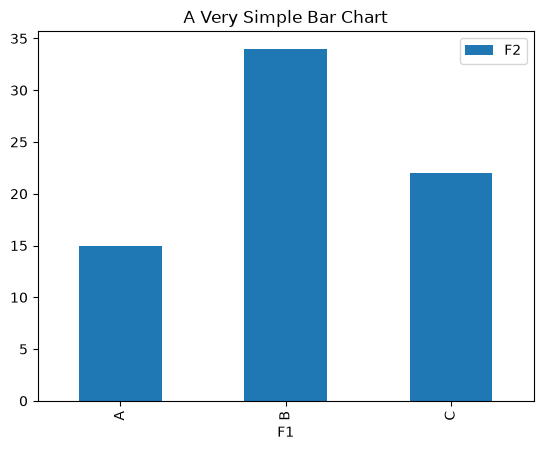

In [5]:
df1.plot(kind='bar', x='F1', y='F2', title="A Very Simple Bar Chart")
plt.show()

Stop and inspect the resulting chart. 

:::{admonition} Question

Where did each of the elements of the data frame land on the chart?

:::

:::{admonition} Answer
:class: dropdown

- F1 name $\rightarrow$ x axis label
- F1 domain $\rightarrow$ x axis scale
- F1 values $\rightarrow$ positions of bars on x axis
- F2 name $\rightarrow$ the legend
- F2 domain $\rightarrow$ y axis scale
- F2 values $\rightarrow$ height of bars on y axis

:::

Let's clean the figure up a bit. 

First, let's remove the legend since it is not really needed in this example.

Second, let's rotate the letters on the x axis for readability.

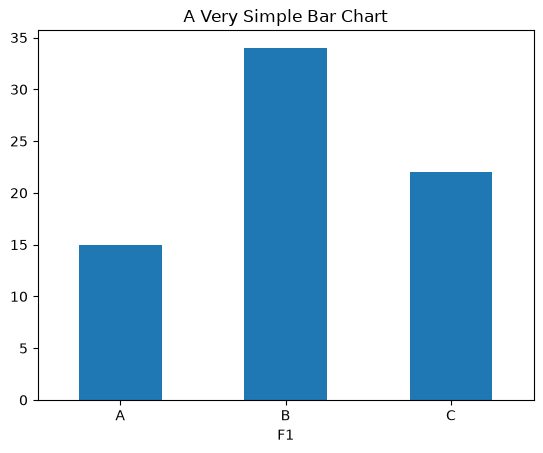

In [6]:
df1.plot(kind='bar', x='F1', y='F2', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

To create a horizontal chart, we set `kind` to `barh`.

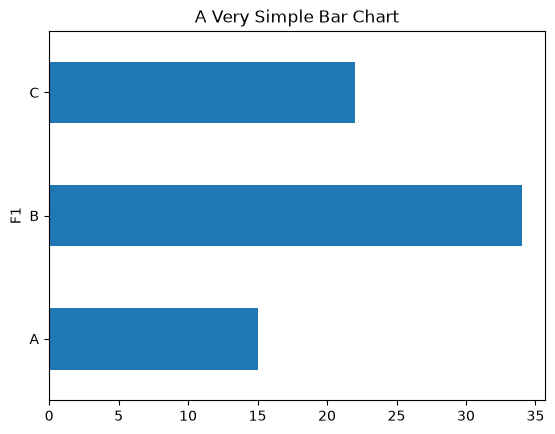

In [7]:
df1.plot(kind='barh', x='F1', y='F2', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

Note that instead of using the argument `kind`, we can call `bar` and `barh` as chained methods to `.plot()`, like so:


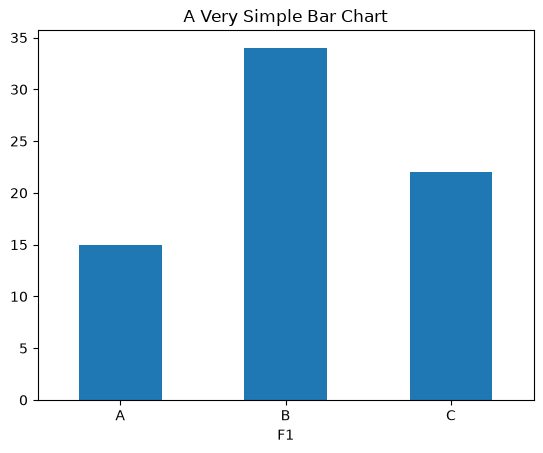

In [8]:
df1.plot.bar(x='F1', y='F2', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

## Plotting with indexes

Note that if we do not set the value of `x`, Pandas will use the index as the x axis.

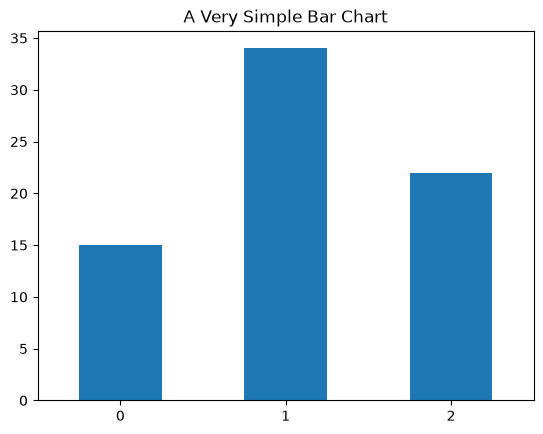

In [9]:
df1.plot.bar(y='F2', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

In fact, it is a good practice to assign the categorical feature to be the index in this case.

Since the values are unique, they can used as index values. 

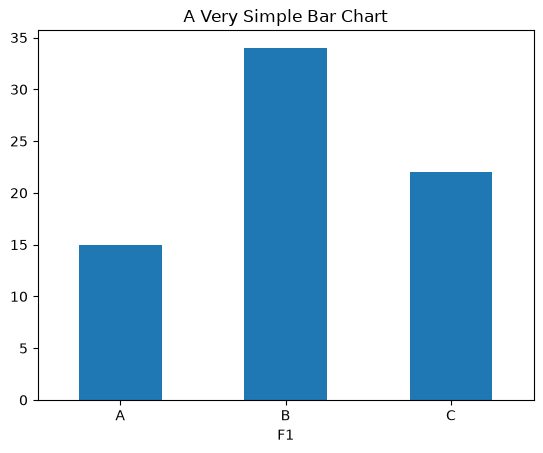

In [10]:
df2 = df1.set_index('F1')
df2.plot.bar(y='F2', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

Note also that if we pass a series to the plot method, by selecting a feature, we don't need to specify the `y` argument either.

In [11]:
df2['F2']

F1
A    15
B    34
C    22
Name: F2, dtype: int64

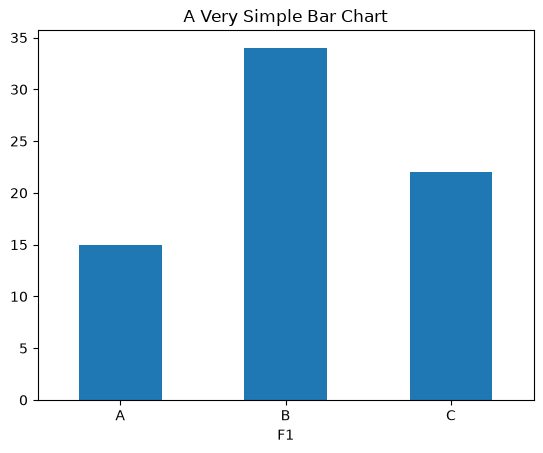

In [12]:
df2['F2'].plot.bar(title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

:::{tip}

This is an important pattern to remember: selecting and shaping your data before visualization often makes the visualization code simpler.

:::

## A more complex example

In the preceding example we had a data set in which unique categorical feaatures are paired with numberic values.

In reality, we don't often get data like this. More typically, the nominal values are repeated over observations.

Consider the Iris data set, which we will grab from the PyDataset library.

In [13]:
import pydataset

iris = pydataset.data('iris')
iris.columns = [col.lower().replace(".", "_") for col in iris.columns]
iris.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.3,5.7,2.5,virginica
26,5.0,3.0,1.6,0.2,setosa
77,6.8,2.8,4.8,1.4,versicolor
119,7.7,2.6,6.9,2.3,virginica
56,5.7,2.8,4.5,1.3,versicolor
37,5.5,3.5,1.3,0.2,setosa
100,5.7,2.8,4.1,1.3,versicolor
149,6.2,3.4,5.4,2.3,virginica
45,5.1,3.8,1.9,0.4,setosa
116,6.4,3.2,5.3,2.3,virginica


Notice the repetition of the nominal feature `species`.

To plot this feature against any of the other numeric features, we need to group the other features by the nominal feature and grab an aggregate value, such as median, sum, or mean.

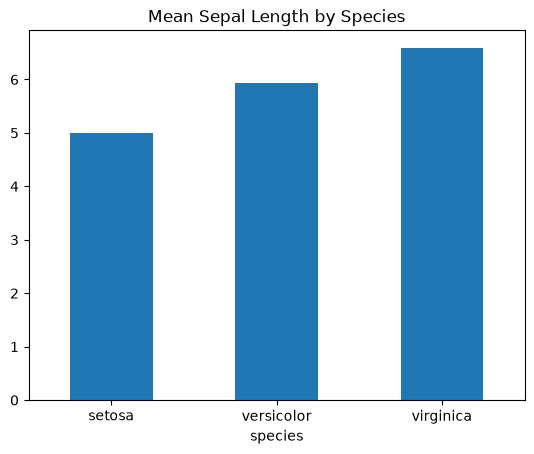

In [14]:
(
    iris.groupby(['species']).sepal_length.mean()
    .plot.bar(rot=0, title="Mean Sepal Length by Species")
)
plt.show()

Another thing we can do is just get the number of instances of a particular value in the nominal column.

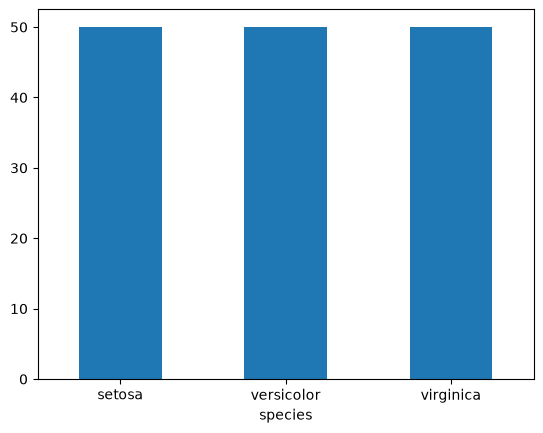

In [15]:
iris.species.value_counts().plot.bar(rot=0)
plt.show()

Here we can see that the data set is balanced over species &mdash; there are $50$ observations per species.

## Multiple categories

What if we want to compare the magnitudes of more than one numeric feature across a nominal feature, in this case species?

Let's experiment to find out. 

First, we get the mean of all the features by grouping on species and not specifying any columns to aggregate. Pandas will interpret this as saying you want all the columns aggregated. 

> Note that you should only do this if the columns are all numeric and come from the same domain. 

In [16]:
iris_means = iris.groupby('species').mean()
iris_means

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Now, when we call `plot.bar()`, Pandas creates a bar chart for each feature and then combines them.

By default, it combines them into groups.

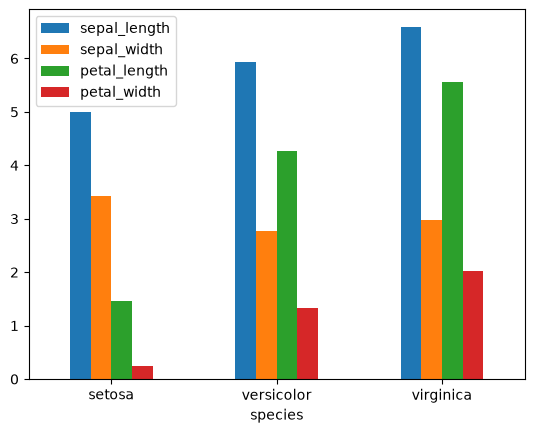

In [17]:
iris_means.plot.bar(rot=0)
plt.show()

We can also combine them by stacking if we set `stacked = True`.

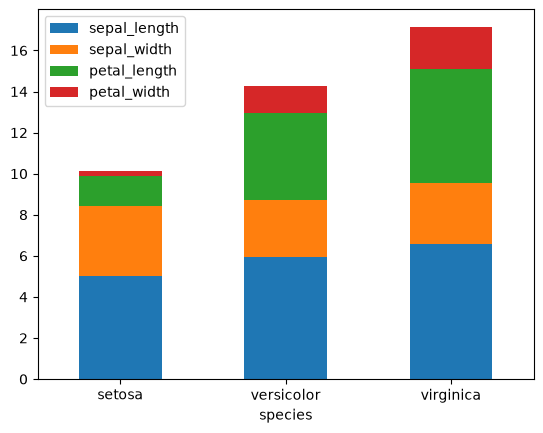

In [18]:
iris_means.plot.bar(rot=0, stacked=True)
plt.show()

Finally, we can use `subplot = True` to create a separate plot for each feature.

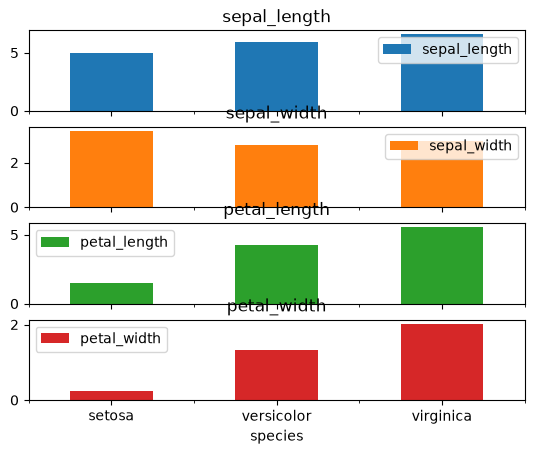

In [19]:
iris_means.plot.bar(rot=0, subplots=True)
plt.show()

Notice that this figure needs some work to improve its legibility.

Let's change the size of the figure to give each plot more room. 

To do this, we set `figsize = (5,10)`, i.e. we set width to $5$ and height to $10$. 

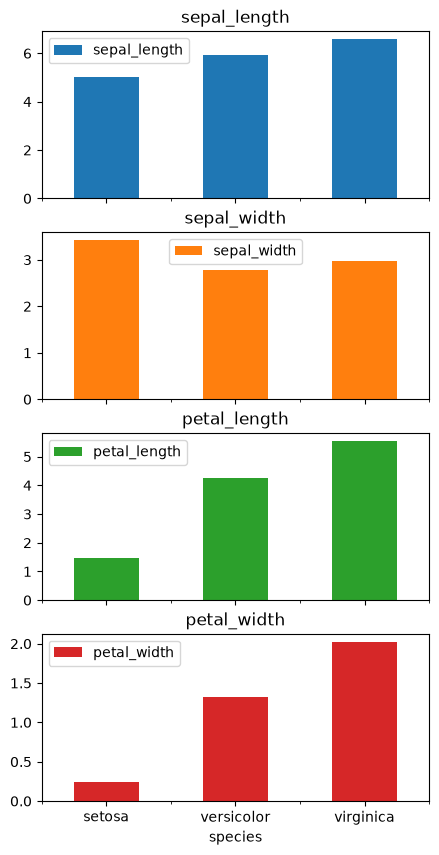

In [20]:
iris_means.plot.bar(rot=0, subplots=True, figsize=(5,10))
plt.show()

## Changing category order

Finally, we can transpose the table to change the priority of categories.

The order of representation is as follows: Each observation row gets a bar, and each feature column gets a plot.

So, if we want each species to get its own plot with features as bars, we can use the `.T` operation to flip the table.

In [21]:
iris_means.T

species,setosa,versicolor,virginica
sepal_length,5.006,5.936,6.588
sepal_width,3.428,2.770,2.974
petal_length,1.462,4.260,5.552
petal_width,0.246,1.326,2.026


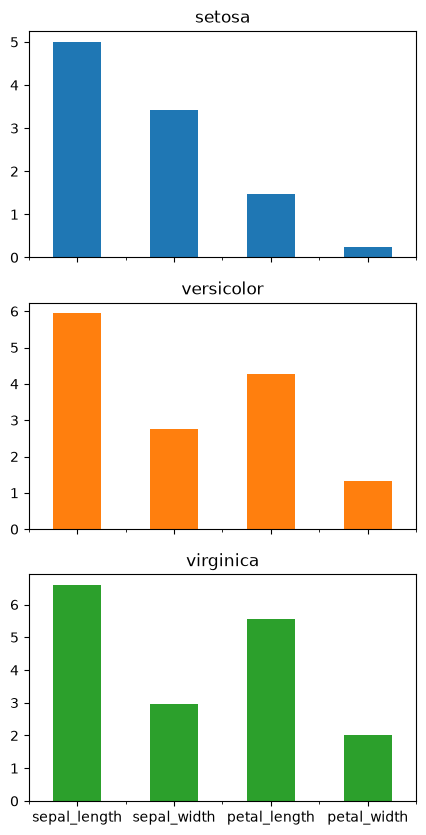

In [22]:
iris_means.T.plot.bar(rot=0, subplots=True, figsize=(5,10), legend=False)
plt.show()

Of course, we can recreate the plots we made above with the new transposed table.

This plot shows the relative magnitudes of each feature over species.

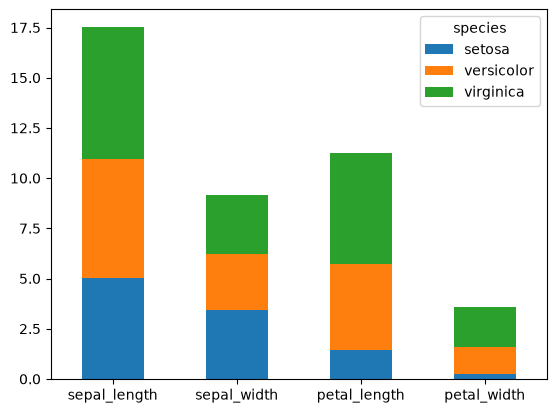

In [23]:
iris_means.T.plot.bar(rot=0, stacked=True)
plt.show()

## Next steps

- Have students copy this notebook with another data, e.g. `penguins`.
- Create 5 question quiz